In [ ]:
# Install hypertools (run this first on Colab)
%pip install -q "hypertools[interactive]"

# Hierarchical DataFrames: plotting and forecasting a column MultiIndex

A pandas `MultiIndex` says that your observations, or your features, come in groups. Since 1.1, `hyp.plot` and `hyp.predict` read that structure instead of flattening it away. The whole feature rests on one distinction:

* a **row** `MultiIndex` groups **observations**;
* a **column** `MultiIndex` groups **features**, and its *innermost* level **is** the feature axis. Every level above it does the grouping.

This notebook builds a column hierarchy from a hosted example dataset, plots it (every group plus its mean, styled by level), carries a continuous `hue=` through it, forecasts it with `hyp.predict` and with `predict=` inside `plot`, looks at what `return_model=True` hands back, shows the calls the hierarchy refuses, and ends with the row form for contrast. The *Hierarchical DataFrames* guide in the documentation states the rules in full; this is the executable tour.

## Import packages

In [1]:
import warnings

import numpy as np
import pandas as pd

import hypertools as hyp

%matplotlib inline

## Build a column hierarchy

`weights_sample` holds three subjects' brain responses while they listened to a story: three arrays of 300 timepoints by 100 features, and the 100 features mean the same thing for every subject. That is exactly the shape a column hierarchy describes. The arrays are smoothed first with `hyp.manip` so the trajectories are legible rather than a tangle, and then `hypertools.tools.stack` builds the column hierarchy in one call: the innermost column level names the **features** (shared across subjects), `Subject` groups them, and a constant top level, `Group`, is what gives the hierarchy a mean to draw. Feature correspondence across groups is by **name**, so every group must carry the same innermost labels.

In [2]:
subjects = [s.to_numpy() for s in hyp.manip(hyp.load('weights_sample'), model='Smooth', kernel_width=25)]
frame = hyp.stack({'listeners': subjects},
                  names=[f'subject {i + 1}' for i in range(len(subjects))],
                  level_names=['Group', 'Subject', 'Feature'])
print(frame.shape, frame.columns.nlevels, 'column levels', frame.columns.names)
frame.columns[:3].tolist() + ['...'] + frame.columns[-2:].tolist()

(300, 300) 3 column levels ['Group', 'Subject', 'Feature']


[('listeners', 'subject 1', 'feature 1'),
 ('listeners', 'subject 1', 'feature 2'),
 ('listeners', 'subject 1', 'feature 3'),
 '...',
 ('listeners', 'subject 3', 'feature 99'),
 ('listeners', 'subject 3', 'feature 100')]

## One call: the leaves plus their mean

Passing the bare frame draws one trajectory per `(Group, Subject)` leaf and then one **mean** per grouping level above the leaves -- here a single mean over the three subjects, built in display space after the reduction. The hierarchy sets the style: `linewidth = 1 + (n_levels - 1 - level_idx)` and `alpha = min(1, 1 / (level_idx + 1) + 0.2)`, so leaves are thin and translucent and the top-level mean is heavier and opaque. Colour is assigned per **top-level** value, so every trace under `listeners` shares one colour and is told apart by weight and opacity, and only the top-level mean carries a legend label.

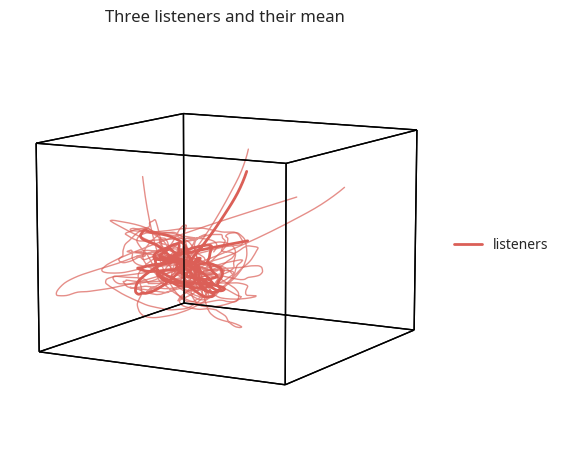

In [3]:
fig = hyp.plot(frame, title='Three listeners and their mean')

## The style belongs to the hierarchy

Because the hierarchy owns `alpha`, `linewidth` and `color`, passing them is not an error but is ignored with a `UserWarning` (caught and printed below so it is visible). `legend=` is the one styling kwarg that is honoured: a list renames the top-level groups, one entry per unique top-level value, and `legend=False` suppresses the legend.

x has a column MultiIndex: MultiIndex grouping assigns alpha by level (leaves most transparent, top-level means fully opaque); ignoring alpha.


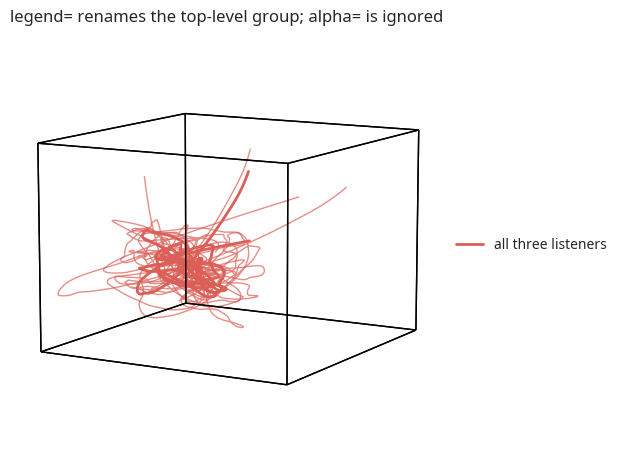

In [4]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    fig = hyp.plot(frame, alpha=0.3, legend=['all three listeners'],
                   title='legend= renames the top-level group; alpha= is ignored')
print([str(w.message) for w in caught if 'alpha' in str(w.message)][0])

## A continuous `hue=` carried through the hierarchy

A continuous `hue=` is carried *through* a column hierarchy rather than superseded by it. Give it one value per **input row** (here the timepoint) and every trace is coloured by it; a mean trace takes the element-wise mean of its members' hue, computed by the same operation that averages their data. One colour scale spans every trace, so `colorbar=` reads against all of them. The per-trace values come back as `trace_metadata['aux']`.

one hue sequence per trace: [(300,), (300,), (300,), (300,)]
the mean trace carries the mean of its members' hue: True


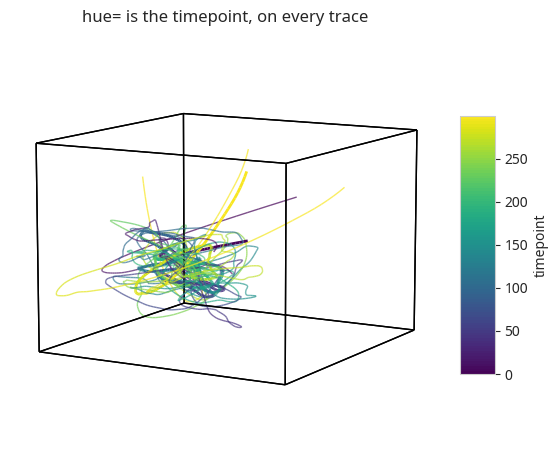

In [5]:
timepoints = np.arange(len(frame))
bundle = hyp.plot(frame, hue=timepoints, palette='viridis',
                  colorbar={'label': 'timepoint'}, return_model=True,
                  title='hue= is the timepoint, on every trace')
aux = bundle['trace_metadata']['aux']
print('one hue sequence per trace:', [a.shape for a in aux])
print('the mean trace carries the mean of its members\' hue:',
      bool(np.allclose(aux[-1], np.mean(aux[:-1], axis=0))))

## Forecasting the frame with `hyp.predict`

`hyp.predict` groups a column-hierarchical frame the same way `plot` does and fits **one model per group**: the result is a list of forecasts, one per leaf in input order, and each keeps the innermost level's feature names as its columns. With `return_model=True` it returns the parallel pair `(forecasts, models)` rather than a list of pairs, and every model is a distinct fitted object.

In [6]:
forecasts, models = hyp.predict(frame, model='Kalman', t=12, return_model=True)
print('one forecast per group:', [f.shape for f in forecasts])
print('columns are the feature names:', forecasts[0].columns[:3].tolist())
print('one fitted model per group:', [m.is_fitted for m in models],
      'distinct objects:', len({id(m) for m in models}) == len(models))

one forecast per group: [(12, 100), (12, 100), (12, 100)]
columns are the feature names: ['feature 1', 'feature 2', 'feature 3']
one fitted model per group: [True, True, True] distinct objects: True


## `predict=` inside `plot`

Inside `plot`, forecasting happens in the plotted space and the unit is the **final trace**: one forecast per leaf *and* one per derived mean, each mean forecast from its own averaged trajectory rather than from an average of its members' forecasts. Note that `t=` is a `plot` keyword in its own right, not a key inside the `predict=` spec. Forecasting needs history, so every final trace must have at least 2 rows -- for a column hierarchy that means the frame itself has at least 2 rows, since every group keeps all of them.

bundle keys: ['animation', 'colors', 'fig', 'models', 'pipeline', 'predict', 'trace_data', 'trace_metadata', 'xform_data']
forecasts, one per FINAL trace: [(12, 3), (12, 3), (12, 3), (12, 3)]
drawn: True


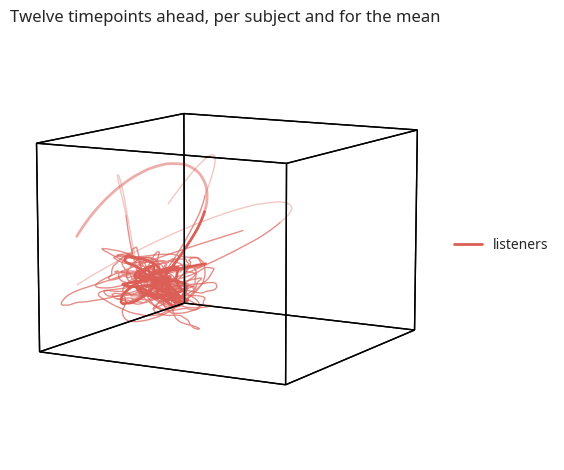

In [7]:
bundle = hyp.plot(frame, predict='Kalman', t=12, return_model=True,
                  title='Twelve timepoints ahead, per subject and for the mean')
print('bundle keys:', sorted(bundle))
print('forecasts, one per FINAL trace:', [f.shape for f in bundle['predict']['forecasts']])
print('drawn:', bundle['predict']['drawn'])

## What `trace_data` and `trace_metadata` hold

`xform_data` is the analysed pipeline output, one entry per **input** dataset -- for a hierarchy, one per leaf. `trace_data` is the final pre-centre/pre-scale plotted trajectories: the leaves followed by the per-level means, which are presentation artifacts and so are deliberately absent from `xform_data`. `trace_metadata` describes every entry of `trace_data` positionally (`keys`, `level_idx`, `is_mean`, and `aux` when a continuous hue was carried), plus the whole-hierarchy `axis` and `level_names`; it is `None` for non-hierarchical input.

The bundle's `pipeline` was fit on the frame's **groups**, each as wide as one group, and remembers the grouping: `.transform(frame)` groups the frame first and returns one array per group, matching features by name.

In [8]:
meta = bundle['trace_metadata']
print('xform_data entries:', len(bundle['xform_data']), '(one per leaf)')
print('trace_data entries:', len(bundle['trace_data']), '(leaves, then means)')
print('keys:     ', meta['keys'])
print('level_idx:', meta['level_idx'])
print('is_mean:  ', meta['is_mean'])
print('axis / level_names:', meta['axis'], meta['level_names'])
print('pipeline.transform(frame):', [np.asarray(a).shape for a in bundle['pipeline'].transform(frame)])

xform_data entries: 3 (one per leaf)
trace_data entries: 4 (leaves, then means)
keys:      [('listeners', 'subject 1'), ('listeners', 'subject 2'), ('listeners', 'subject 3'), ('listeners',)]
level_idx: [1, 1, 1, 0]
is_mean:   [False, False, False, True]
axis / level_names: columns ['Group', 'Subject']
pipeline.transform(frame): [(300, 3), (300, 3), (300, 3)]


## What is refused, and why

Some combinations are ambiguous and are refused rather than guessed at. A frame with a hierarchy on **both** axes has no defined precedence. Groups that name **different** innermost features -- one ticker per sector, say -- cannot be matched by name; the fix is to make the innermost level shared measurements and move the identifiers up a level. `names=` assigns one name per input *dataset*, but a hierarchy draws groups plus means, so it points at `legend=[...]` instead. And `cluster=` would fight the hierarchy's colour assignment on either axis.

In [9]:
rng = np.random.default_rng(0)
dual = pd.DataFrame(rng.standard_normal((8, 2)),
                    index=pd.MultiIndex.from_product([['A', 'B'], range(4)], names=['g', 't']),
                    columns=pd.MultiIndex.from_product([['S'], ['x', 'y']], names=['grp', 'feat']))
by_ticker = pd.DataFrame(rng.standard_normal((20, 4)),
                         columns=pd.MultiIndex.from_tuples(
                             [('Tech', 'AAPL'), ('Tech', 'MSFT'), ('Energy', 'XOM'), ('Energy', 'CVX')],
                             names=['Sector', 'Ticker']))
refused = [('a hierarchy on both axes', lambda: hyp.plot(dual)),
           ('groups with different features', lambda: hyp.predict(by_ticker, model='Kalman', t=2)),
           ('names= on a hierarchy', lambda: hyp.plot(frame, names=['a', 'b', 'c', 'd'])),
           ('cluster= on a hierarchy', lambda: hyp.plot(frame, cluster='KMeans', n_clusters=2))]
for label, call in refused:
    try:
        call()
    except ValueError as error:
        print(f'{label}:\n    {str(error).split(". ")[0]}\n')

a hierarchy on both axes:
    x has both a row and a column MultiIndex

groups with different features:
    column-hierarchy group ('Energy',) does not have the same features as the first group ('Tech',): missing ['AAPL', 'MSFT'], unexpected ['XOM', 'CVX']

names= on a hierarchy:
    names= assigns one name per input dataset, but x has a column MultiIndex, so the drawn traces are hierarchy groups (3 leaf trajectory/ies + 1 derived per-level mean(s)), not input datasets

cluster= on a hierarchy:
    cluster=/n_clusters= is not compatible with a column-MultiIndex DataFrame: MultiIndex grouping already assigns colors by the top-level column index and would conflict with cluster-based grouping



## The row-MultiIndex form, for contrast

The same three subjects stacked **vertically** give a `(Subject, time)` row hierarchy. `hyp.predict` treats the innermost row level as the time axis and groups by the outer levels, so it still returns one forecast per subject. `hyp.plot` draws one trace per unique **full** index tuple, so a `time` level that is unique per row yields 900 one-row traces -- and `predict=` refuses that, naming the remedy (drop the hierarchy, or move the grouping to the columns). A row hierarchy whose innermost level *repeats* -- each subject's timepoints split into two halves -- is drawn as six leaves plus one mean per subject.

predict groups by Subject: [(12, 100), (12, 100), (12, 100)]


plot(..., predict=) on unique-per-row times:
    plot(..., predict=...) needs at least 2 rows per trace, but trace 0 ('subject 1', 0) has 1 row
[('subject 1', 'first half'), ('subject 1', 'second half'), ('subject 2', 'first half'), ('subject 2', 'second half'), ('subject 3', 'first half'), ('subject 3', 'second half'), ('subject 1',), ('subject 2',), ('subject 3',)]


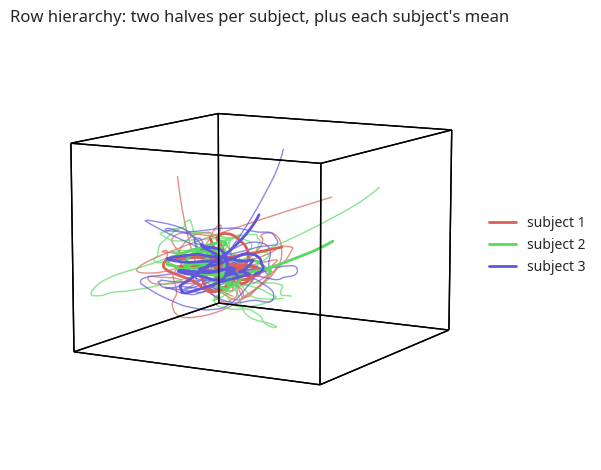

In [10]:
rows = pd.concat({f'subject {i + 1}': pd.DataFrame(data) for i, data in enumerate(subjects)}, axis=0)
rows.index.names = ['Subject', 'time']
print('predict groups by Subject:', [f.shape for f in hyp.predict(rows, model='Kalman', t=12)])
try:
    hyp.plot(rows, predict='Kalman', t=12)
except ValueError as error:
    print('plot(..., predict=) on unique-per-row times:\n   ', str(error).split('. ')[0])

halves = pd.concat({(f'subject {i + 1}', half): pd.DataFrame(data[k * 150:(k + 1) * 150])
                    for i, data in enumerate(subjects)
                    for k, half in enumerate(('first half', 'second half'))}, axis=0)
halves.index = halves.index.droplevel(-1)
halves.index.names = ['Subject', 'Half']
bundle = hyp.plot(halves, return_model=True, title='Row hierarchy: two halves per subject, plus each subject\'s mean')
print(bundle['trace_metadata']['keys'])

## Where to go next

The *Hierarchical DataFrames* guide covers the parts this tour skipped: matrix (mixture-weight) hues, `hue_mode=`, unequal-length row groups, the escape hatch for positional correspondence, and how group order interacts with the shared reduction. The market-sectors tutorial builds the bold-mean / faint-leaves picture from a list of sectors instead, with `hyp.reduce` and `hyp.align` called explicitly.